# Loan Approval Prediction Model

In [812]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
df=pd.read_csv("loan_approval_dataset.csv")
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [813]:
df.head(3)

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected


In [814]:
df.dropna(axis=1, inplace = True)
#it drop columns  having NaN values

In [815]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [816]:
df.shape

(4269, 13)

In [817]:
# drop column LOAN ID
df.drop("loan_id", axis = 1, inplace = True)
df.shape

(4269, 12)

In [818]:
df.head(2)

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected


In [819]:
df.describe()

,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [820]:
df.isnull().sum()

no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64

In [821]:
df.columns

Index([' no_of_dependents', ' education', ' self_employed', ' income_annum',
       ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='object')

In [822]:
df.columns=df.columns.str.strip()
df.columns

Index(['no_of_dependents', 'education', 'self_employed', 'income_annum',
       'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value',
       'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value',
       'loan_status'],
      dtype='object')

In [823]:
df.education.unique()

array([' Graduate', ' Not Graduate'], dtype=object)

In [824]:
def clean_data(st):
    st=st.strip()
    return st

In [825]:
clean_data('Graduate')

'Graduate'

In [826]:
df.education = df.education.apply(clean_data)

# Changing Categorical to Numerical values -- Manual Mapping

In [827]:
df['education'] = df['education'].replace(['Graduate','Not Graduate'],[1,0])
df

C:\Users\piyus\AppData\Local\Temp\ipykernel_15376\2288919991.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['education'] = df['education'].replace(['Graduate','Not Graduate'],[1,0])


,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,1,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,0,0,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,1,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,1,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,0,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...
4264,5,1,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,0,0,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,2,0,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,1,0,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


In [828]:
df.self_employed.unique()

array([' No', ' Yes'], dtype=object)

In [829]:
df.self_employed = df.self_employed.apply(clean_data)

In [830]:
df.self_employed.unique()

array(['No', 'Yes'], dtype=object)

In [831]:
df.self_employed = df.self_employed.replace(['No','Yes'],[0,1])
df

C:\Users\piyus\AppData\Local\Temp\ipykernel_15376\239851529.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.self_employed = df.self_employed.replace(['No','Yes'],[0,1])


,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,1,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,0,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,1,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,1,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,0,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...
4264,5,1,1,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,0,0,1,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,2,0,0,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,1,0,0,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


In [832]:
df.loan_status.unique()

array([' Approved', ' Rejected'], dtype=object)

In [833]:
df.loan_status = df.loan_status.apply(clean_data)

In [834]:
df.loan_status.unique()

array(['Approved', 'Rejected'], dtype=object)

In [835]:
df.loan_status = df.loan_status.replace(['Approved','Rejected'],[1,0])
df

C:\Users\piyus\AppData\Local\Temp\ipykernel_15376\1070416262.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.loan_status = df.loan_status.replace(['Approved','Rejected'],[1,0])


,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,1,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,1
1,0,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0
2,3,1,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0
3,3,1,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0
4,5,0,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...
4264,5,1,1,1000000,2300000,12,317,2800000,500000,3300000,800000,0
4265,0,0,1,3300000,11300000,20,559,4200000,2900000,11000000,1900000,1
4266,2,0,0,6500000,23900000,18,457,1200000,12400000,18100000,7300000,0
4267,1,0,0,4100000,12800000,8,780,8200000,700000,14100000,5800000,1


# EDA Process Completed 

# Seperating Input and Output

In [836]:
input_data = df.drop(columns=['loan_status'])
output_data = df['loan_status']

In [837]:
input_data

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
0,2,1,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000
1,0,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000
2,3,1,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000
3,3,1,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000
4,5,0,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000
...,...,...,...,...,...,...,...,...,...,...,...
4264,5,1,1,1000000,2300000,12,317,2800000,500000,3300000,800000
4265,0,0,1,3300000,11300000,20,559,4200000,2900000,11000000,1900000
4266,2,0,0,6500000,23900000,18,457,1200000,12400000,18100000,7300000
4267,1,0,0,4100000,12800000,8,780,8200000,700000,14100000,5800000


In [838]:
output_data

0       1
1       0
2       0
3       0
4       0
       ..
4264    0
4265    1
4266    0
4267    1
4268    1
Name: loan_status, Length: 4269, dtype: int64

In [839]:
from sklearn.model_selection import train_test_split

In [840]:
x=df.iloc[:,0:-1].values
y=df.iloc[:,-1].values

In [841]:
x_train,x_test,y_train,y_test=train_test_split(x,y, test_size=0.20, random_state=42)

In [842]:
print("shape of x:",x.shape)
print("shape of y:",y.shape)

shape of x: (4269, 11)
shape of y: (4269,)


In [843]:
print("print x_train:",x_train.shape)
print("print x_test:",x_test.shape)

print x_train: (3415, 11)
print x_test: (854, 11)


In [844]:
print("print y_train:",y_train.shape)
print("print y_test:",y_test.shape)

print y_train: (3415,)
print y_test: (854,)


# Random Forest Algorithm

In [845]:
from sklearn.ensemble import RandomForestClassifier

In [846]:
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=10,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42
)

rf.fit(x_train, y_train)

y_pred = rf.predict(x_test)


In [847]:
cr_g=RandomForestClassifier(n_estimators=100,criterion='gini')
# we use both parameter default values
cr_g.fit(x_train,y_train)
cr_g.score(x_test,y_test)

0.9800936768149883

In [848]:
cr_g=RandomForestClassifier(n_estimators=120,criterion='entropy')
# we use both parameter default values
cr_g.fit(x_train,y_train)
cr_g.score(x_test,y_test)

0.9812646370023419

In [849]:
# Predicition
cr_g.predict([x_test[0,:]])

array([0])

In [850]:
y_test

array([0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0,
       0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1,
       0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1,
       1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1,
       1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1,
       1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0,

In [851]:
y_pred=cr_g.predict(x_test)

In [852]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
import matplotlib.pyplot as plt

<Axes: >

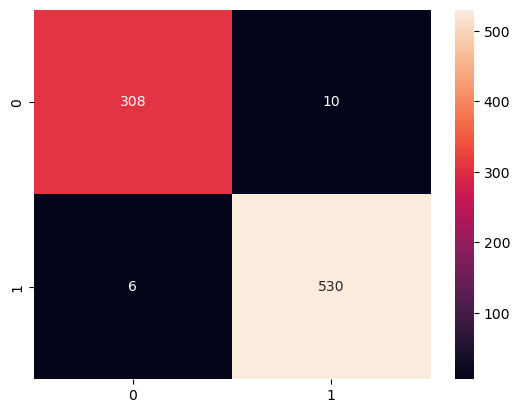

In [853]:
sns.heatmap(cm,annot=True,fmt='g')

In [854]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

In [855]:
cm=confusion_matrix(y_test,y_pred)

In [856]:
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)

Accuracy: 0.9812646370023419


In [857]:
pre=precision_score(y_test,y_pred)
print("Precision:",pre)

Precision: 0.9814814814814815


In [858]:
re=recall_score(y_test,y_pred)
print("Recall:",re)

Recall: 0.9888059701492538


In [859]:
f1=f1_score(y_test,y_pred)
print("F1:",f1)

F1: 0.9851301115241635


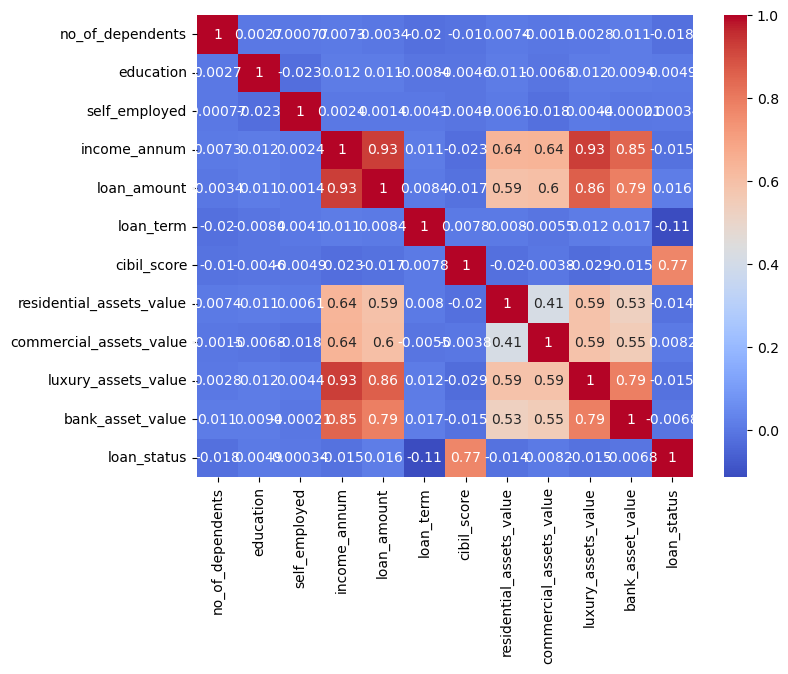

In [860]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

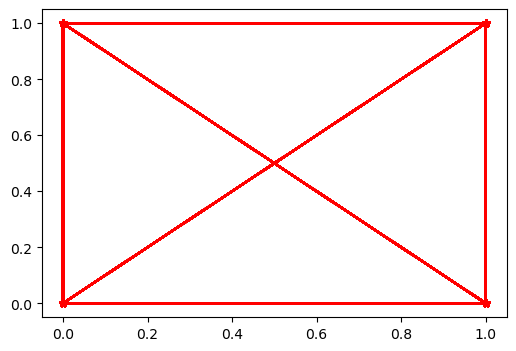

In [861]:
plt.figure(figsize=(6,4))
plt.plot(df['education'],df['loan_status'],color='r',marker='*')
plt.show

<Axes: xlabel='loan_term'>

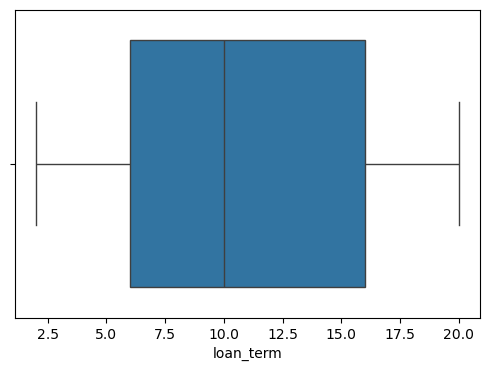

In [862]:
plt.figure(figsize=(6,4))
sns.boxplot(df['loan_term'],orient='h')

<Axes: xlabel='cibil_score'>

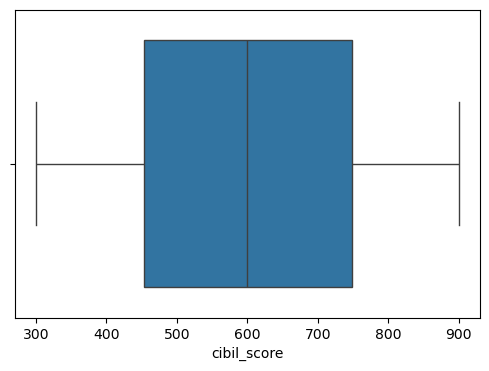

In [863]:
plt.figure(figsize=(6,4))
sns.boxplot(df['cibil_score'],orient='h')

# Model Performance

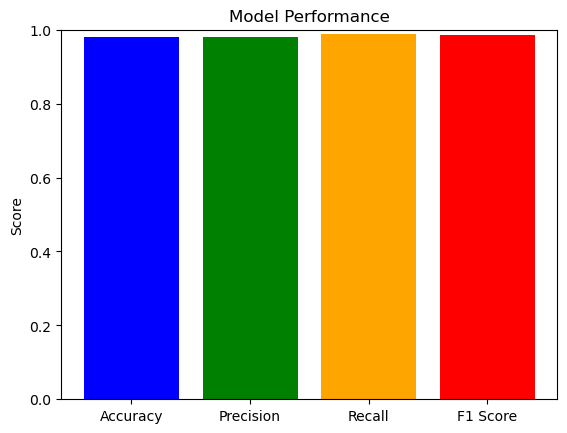

In [864]:
import matplotlib.pyplot as plt

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [accuracy, pre, re, f1]
plt.bar(metrics, values, color=['blue','green','orange','red'])

plt.ylim(0,1)  
plt.title("Model Performance")
plt.ylabel("Score")

plt.show()

In [865]:
rf.fit(x_train, y_train)

,n_estimators,500
,criterion,'gini'
,max_depth,10
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


# Logistic Regression 

In [866]:
# split data into training and testing
from sklearn.model_selection import train_test_split

In [867]:
x_train , x_test , y_train, y_test = train_test_split(x,y, test_size = 0.30)

In [868]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=10000, random_state=0)

In [869]:
# fitting logistic reg on training dataset
model.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,0
,solver,'lbfgs'
,max_iter,10000
,multi_class,'deprecated'


In [870]:
# predict testing data
y_pred = model.predict(x_test)
model.predict_proba(x_test)
# predict_proba() return the probality of data point belongs to each class
# This function used to classifciation model to get probality of each class insted of just the predicted class label .

array([[0.43624306, 0.56375694],
       [0.56815661, 0.43184339],
       [0.19032916, 0.80967084],
       ...,
       [0.24236903, 0.75763097],
       [0.88033372, 0.11966628],
       [0.15895592, 0.84104408]], shape=(1281, 2))

In [871]:
model.score(x_test, y_test)

0.7892271662763466

In [872]:
x_test

array([[       1,        0,        0, ..., 13400000, 22200000,  5300000],
       [       2,        1,        0, ..., 12400000, 19600000,  7100000],
       [       4,        1,        0, ...,  1300000,  5400000,   900000],
       ...,
       [       5,        0,        0, ...,  9500000, 35500000,  5800000],
       [       0,        1,        0, ...,  2600000, 27700000,  5400000],
       [       0,        1,        1, ...,  1400000, 12100000,  3400000]],
      shape=(1281, 11))

In [873]:
# predicting
model.predict(x_test[3].reshape(1,-1))

array([1])

In [874]:
y_test

array([1, 1, 1, ..., 1, 0, 1], shape=(1281,))

# KNN - ( K Nearest Neighbour )

In [875]:
print("shape of x : " , x.shape)
print("shape of y : " , y.shape)

shape of x :  (4269, 11)
shape of y :  (4269,)


In [876]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_train, y_test = train_test_split(x,y, test_size = 0.30 , random_state = 200)

In [877]:
print(" print x_train : " , x_train.shape)
print(" print x_test : " , x_test.shape)

 print x_train :  (2988, 11)
 print x_test :  (1281, 11)


In [878]:
print(" print y_train : " , y_train.shape)
print(" print y_test : " , y_test.shape)

 print y_train :  (2988,)
 print y_test :  (1281,)


In [879]:
from sklearn.neighbors import KNeighborsClassifier

In [880]:
cr = KNeighborsClassifier()
# default value of k is 5
cr.fit(x_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [881]:
cr.score(x_test, y_test)

0.5690866510538641

In [882]:
#changing k value to 10
cr = KNeighborsClassifier(n_neighbors = 10)
cr.fit(x_train, y_train)

,n_neighbors,10
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [883]:
cr.score(x_test, y_test)

0.5644028103044496

In [884]:
cr.predict([x_test[0,:]])

array([1])

In [885]:
y_test

array([1, 1, 0, ..., 1, 0, 0], shape=(1281,))

# Decision Tree

In [886]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split( x, y, test_size = 0.20 , random_state = 51)

In [887]:
print("shape of x_train : " , x_train.shape)
print("shape of x_test : " , x_test.shape)

shape of x_train :  (3415, 11)
shape of x_test :  (854, 11)


In [888]:
print("shape of y_train : " , y_train.shape)
print("shape of y_test : " , y_test.shape)

shape of y_train :  (3415,)
shape of y_test :  (854,)


In [889]:
# check target variables
df["loan_status"].value_counts()

loan_status
1    2656
0    1613
Name: count, dtype: int64

In [890]:
# import model
from sklearn.tree import DecisionTreeClassifier

In [891]:
cr = DecisionTreeClassifier( criterion = "gini")
cr.fit(x_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [892]:
cr.score(x_test , y_test)

0.9730679156908665

In [893]:
cr_e = DecisionTreeClassifier( criterion = "entropy")
cr_e.fit(x_train, y_train)
cr_e.score(x_test, y_test)

0.9812646370023419

In [894]:
# apply standard scalar to input

In [895]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

In [896]:
sc.fit(x_train)

,copy,True
,with_mean,True
,with_std,True


In [897]:
x_train_sc = sc.transform(x_train)
x_test_sc = sc.transform(x_test)

In [898]:
# after scaling apply ml algo
cr = DecisionTreeClassifier( criterion = "gini")
cr.fit(x_train_sc, y_train)
cr.score(x_test_sc, y_test)

0.9754098360655737

In [899]:
cr = DecisionTreeClassifier( criterion = "entropy")
cr.fit(x_train_sc, y_train)
cr.score(x_test_sc, y_test)

0.9800936768149883

# Out of all used algorithms - RANDOM FOREST got the best score and accuracy 

# Model Score Comparison

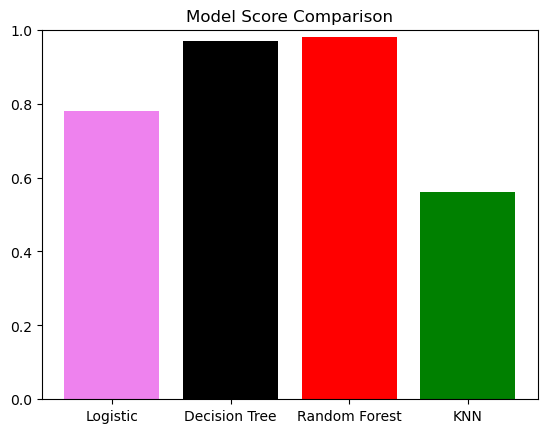

In [900]:
models = ['Logistic', 'Decision Tree', 'Random Forest', 'KNN']
scores = [0.78, 0.97, 0.98, 0.56]

plt.bar(models, scores, color=['violet','black','red','green'])
plt.title("Model Score Comparison")
plt.ylim(0,1)
plt.show()

In [901]:
import pickle

with open("rf_model.pkl", "wb") as f:
    pickle.dump(rf, f)

print("Model saved successfully")

Model saved successfully
